# Visualizing the Sim-to-Real Gap and Stochastic Smoothing

## 1. Introduction: The Problem of Support Mismatch

동역학 시스템의 파라미터 추정(Inverse Problem)을 위해 시뮬레이션 데이터를 사용할 때 가장 큰 문제는 **Sim-to-Real Gap**입니다.
결정론적(Deterministic) ODE 모델은 파라미터($\theta$)가 고정되면 단 하나의 궤적만을 생성하므로, 생성된 데이터 분포 $P_{det}$는 상태 공간 내에서 부피가 없는 **저차원 매니폴드(Manifold)** 위에 갇히게 됩니다.

반면, 실제 데이터 $P_{real}$은 측정 노이즈와 미세한 생물학적 변동성으로 인해 이 매니폴드 주변으로 넓게 퍼져 있습니다.
이로 인해 $P_{det}$와 $P_{real}$의 지지집합(Support)이 겹치지 않는 **Support Mismatch**가 발생하며, 이는 모델 학습 실패의 주원인이 됩니다.

본 노트북에서는 **SDE(Stochastic Differential Equation) 기반 데이터 증강**이 어떻게 결정론적 궤적 주변으로 **확률적 튜브(Stochastic Tube)**를 형성하여 이 문제를 해결하는지 시각적으로 증명합니다.

In [2]:
# 1. Imports & Configuration
import os
import sys
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wasserstein_distance

# 프로젝트 루트 경로 추가 (모듈 import용)
sys.path.append(os.path.abspath(''))

from config import Config
from data_loader import DataGenerator, RealOGTTDataLoader
from systems.ogtt_simul import OgttSimul

# 시각화 스타일 설정
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.unicode_minus'] = False # 마이너스 폰트 깨짐 방지

## 2. Data Preparation

비교 분석을 위해 세 가지 데이터셋을 준비합니다.

1.  **Real Data ($P_{real}$):** NIH OGTT 실제 데이터 ($N \approx 500$). Spline Smoothing을 통해 미분값도 포함되어 있습니다.
2.  **Deterministic ODE ($P_{det}$):** 기존 결정론적 모델 시뮬레이션 ($N = 2000$).
3.  **Stochastic SDE ($P_{sde}$):** 우리가 제안한 Euler-Maruyama 기반 확률적 시뮬레이션 ($N = 2000$).

In [4]:
config = Config()
config.NUM_SAMPLES = 2000  # 시각화용 충분한 샘플 수
config.USE_LAGRANGIAN = True # 미분값 포함 (부록 분석용)
config.SYSTEM_NAME = 'ogtt_vis_proof' # 임시 저장 경로

system = OgttSimul()

print(">>> Loading Real Data...")
# 데이터 경로
real_data_path = 'data/clean_sumner_n_612.xlsx'

real_loader = RealOGTTDataLoader(real_data_path, config)
# X_real: (N, T, 2) -> [Value, Derivative]
X_real, Y_real, _, t_points = real_loader.load_data()

print("\n>>> Generating Deterministic ODE Data (Baseline)...")
config_ode = copy.deepcopy(config)
config_ode.USE_SDE = False
gen_ode = DataGenerator(system, config_ode)
X_ode, Y_ode, _, _ = gen_ode.generate_data()

print("\n>>> Generating Stochastic SDE Data (Proposed)...")
config_sde = copy.deepcopy(config)
config_sde.USE_SDE = True
gen_sde = DataGenerator(system, config_sde)
X_sde, Y_sde, _, _ = gen_sde.generate_data()

print("\nData Preparation Complete.")
print(f"Real: {X_real.shape}, ODE: {X_ode.shape}, SDE: {X_sde.shape}")

# 편의를 위해 변수 분리 (Concentration Only)
# G: Glucose, I: Insulin
G_real, I_real = X_real[:, :, 0], Y_real[:, :, 0]
G_ode, I_ode = X_ode[:, :, 0], Y_ode[:, :, 0]
G_sde, I_sde = X_sde[:, :, 0], Y_sde[:, :, 0]

>>> Loading Real Data...
[RealLoader] Loaded sigma for smoothing: s_G=1346.49, s_I=3463.56
[RealLoader] Derivative Method: spline
Loading real OGTT data from data/clean_sumner_n_612.xlsx...
Data cleaning: Dropped 93 rows with missing values.
Remaining samples: 519

>>> Generating Deterministic ODE Data (Baseline)...
Loaded data-driven distribution parameters for sampling.
Generating 2000 samples using ODE model...
Starting data generation with 8 workers...
Generation complete in 94.19 seconds.
Saving data to data/ogtt_vis_proof/augmented_data_ode_2000.npz...

>>> Generating Stochastic SDE Data (Proposed)...
Loaded data-driven distribution parameters for sampling.
Generating 2000 samples using SDE model...
Starting data generation with 8 workers...
Generation complete in 6.79 seconds.
Saving data to data/ogtt_vis_proof/augmented_data_sde_2000.npz...

Data Preparation Complete.
Real: (519, 5, 2), ODE: (2000, 5, 2), SDE: (2000, 5, 2)


## 3. Visual Proof 1: Time-Series Distribution ($(t, G)$, $(t, I)$)

시간($t$)에 따른 Glucose($G$)와 Insulin($I$)의 분포를 확인합니다.
- **Real Data:** Boxplot으로 실제 데이터의 분포 범위(Variance)를 표시합니다.
- **ODE:** 결정론적 모델의 궤적을 얇은 선으로 표시합니다.
- **SDE:** 확률적 모델의 궤적을 그려, 실제 데이터의 Boxplot 범위를 얼마나 잘 커버하는지 확인합니다.

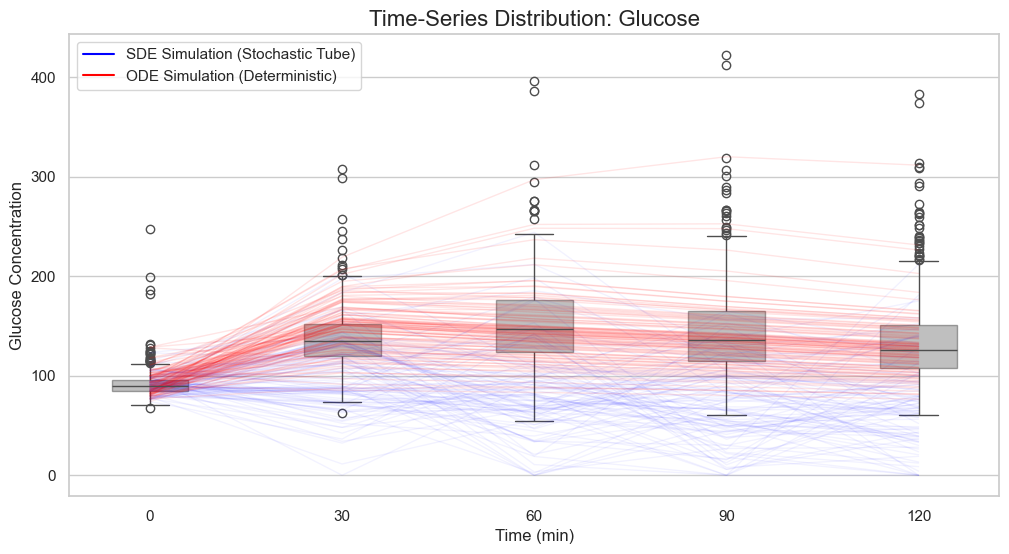

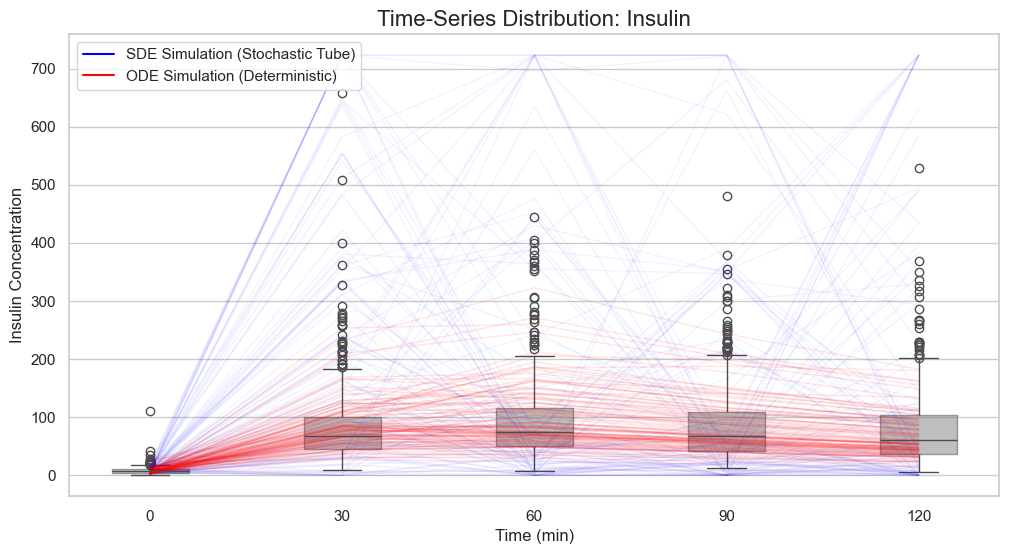

In [5]:
def plot_time_series_distribution(var_name, t_points, real_data, ode_data, sde_data):
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # 1. Real Data (Boxplot)
    # Boxplot은 등간격이 아니면 그리기 어려우므로, 시간축 위치에 맞춰 커스텀하게 그림
    # 여기서는 Seaborn으로 간단히 표현하기 위해 DataFrame 변환
    df_real = pd.DataFrame(real_data, columns=t_points)
    df_real_melt = df_real.melt(var_name='Time', value_name='Value')
    df_real_melt['Type'] = 'Real'
    
    sns.boxplot(x='Time', y='Value', data=df_real_melt, ax=ax, color='gray', width=0.4, boxprops=dict(alpha=0.5))
    
    # 2. Simulation Data (Trajectories)
    # 너무 많으면 지저분하므로 100개만 샘플링하여 그리기
    n_plot = 100
    
    # SDE (Blue Tube)
    for i in range(n_plot):
        ax.plot(range(len(t_points)), sde_data[i], color='blue', alpha=0.05, linewidth=1)
    # Legend용 더미 라인
    ax.plot([], [], color='blue', label='SDE Simulation (Stochastic Tube)')
        
    # ODE (Red Lines)
    for i in range(n_plot):
        ax.plot(range(len(t_points)), ode_data[i], color='red', alpha=0.1, linewidth=1)
    ax.plot([], [], color='red', label='ODE Simulation (Deterministic)')

    ax.set_title(f"Time-Series Distribution: {var_name}", fontsize=16)
    ax.set_xlabel("Time (min)")
    ax.set_ylabel(f"{var_name} Concentration")
    ax.legend()
    plt.show()

# Glucose 그래프
plot_time_series_distribution("Glucose", t_points, G_real, G_ode, G_sde)

# Insulin 그래프
plot_time_series_distribution("Insulin", t_points, I_real, I_ode, I_sde)

## 4. Visual Proof 2: Phase Space Coverage ($(G, I)$)

동역학 시스템의 상태 공간(State Space)인 Glucose-Insulin 평면에서의 분포를 확인합니다.
특히 **$t=30$분 (피크 시점)**과 **$t=120$분 (회복 시점)**에서의 단면(Snapshot)을 비교합니다.

**가설:** ODE 데이터는 1차원 매니폴드(선) 위에 존재하여 실제 데이터(점 구름)를 통과하지 못할 것이다. SDE 데이터는 부피를 가진 구름 형태로 실제 데이터를 감쌀 것이다.

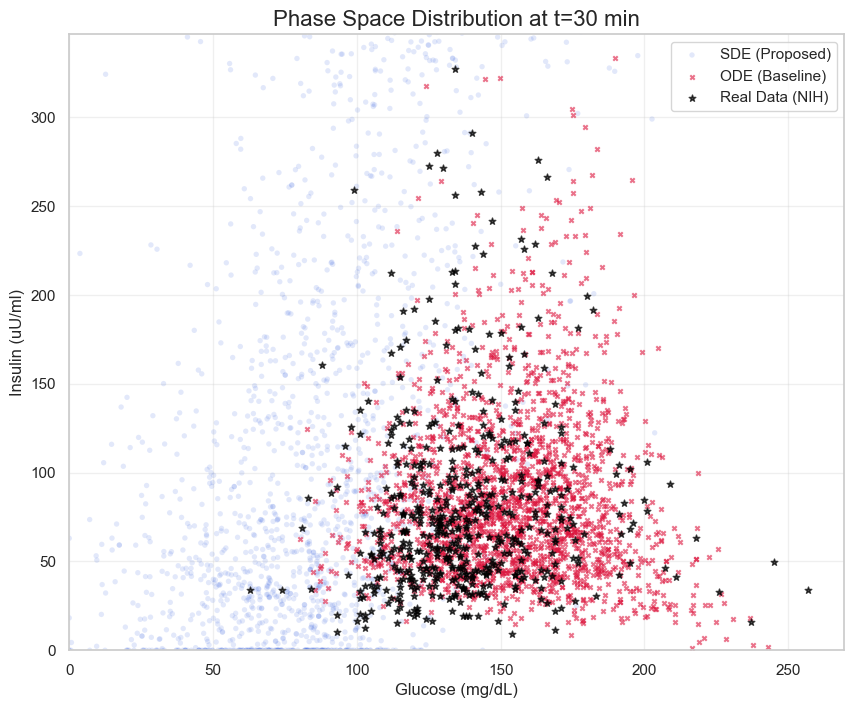

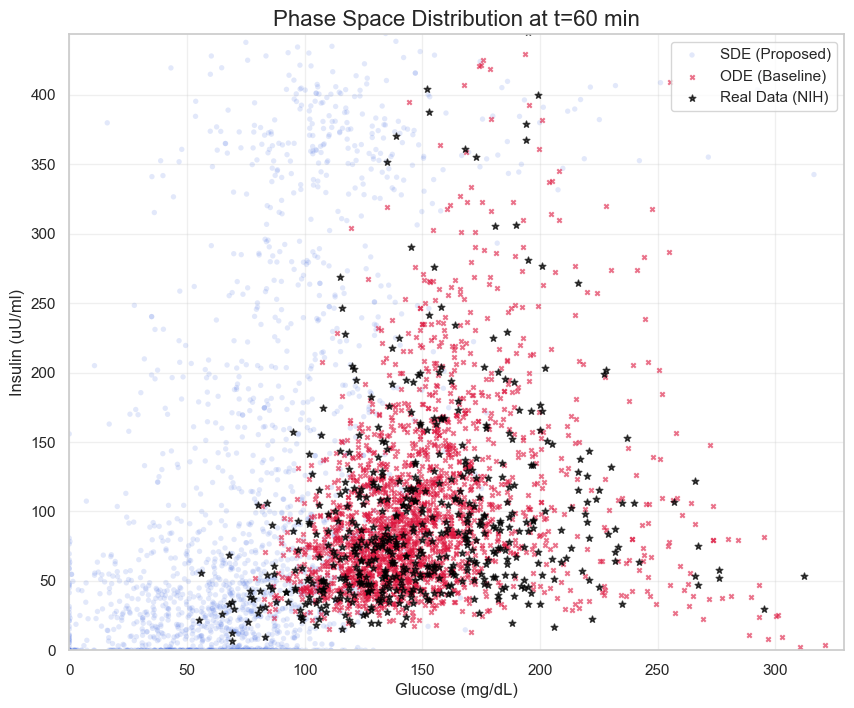

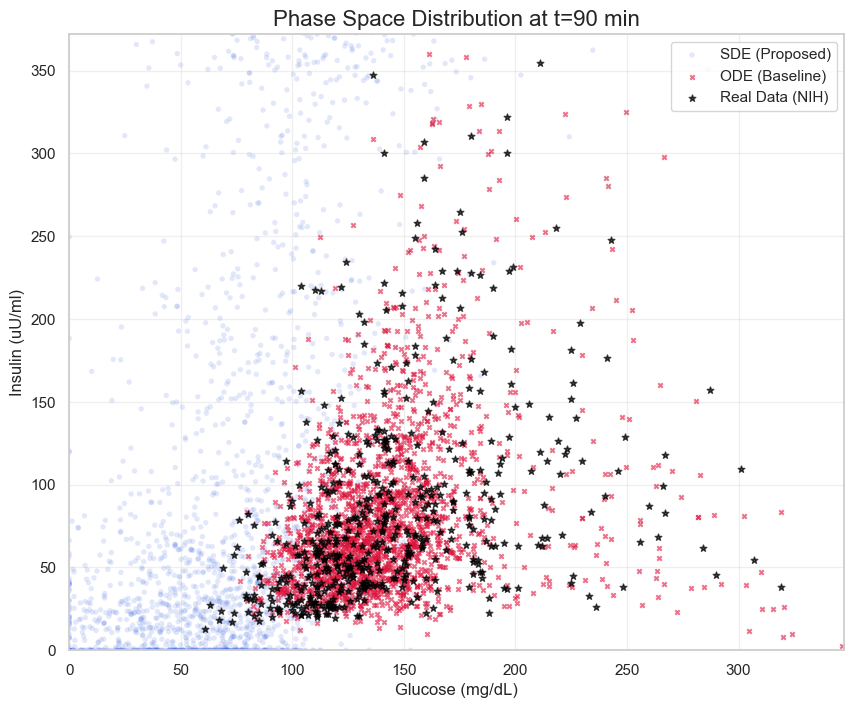

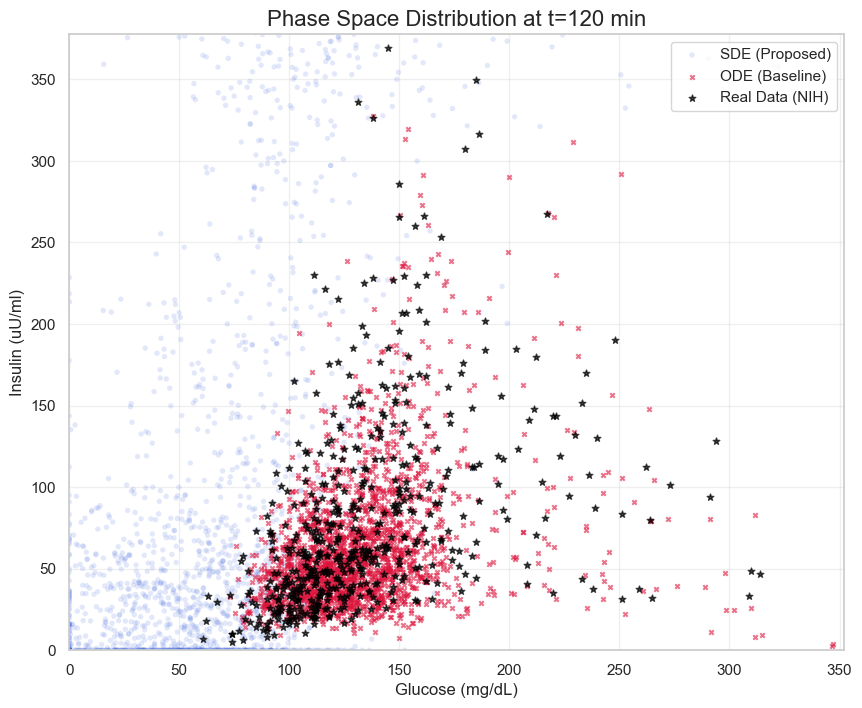

In [7]:
def plot_phase_space(time_idx, time_label):
    plt.figure(figsize=(10, 8))
    
    # SDE (Background Cloud) - 먼저 그려서 배경으로 둚
    plt.scatter(G_sde[:, time_idx], I_sde[:, time_idx], 
                c='royalblue', alpha=0.15, s=15, label='SDE (Proposed)', edgecolors='none')
    
    # ODE (Manifold Line)
    plt.scatter(G_ode[:, time_idx], I_ode[:, time_idx], 
                c='crimson', alpha=0.6, s=10, label='ODE (Baseline)', marker='x')
    
    # Real (Target Distribution)
    plt.scatter(G_real[:, time_idx], I_real[:, time_idx], 
                c='black', alpha=0.7, s=25, label='Real Data (NIH)', marker='*')
    
    plt.title(f"Phase Space Distribution at t={time_label} min", fontsize=16)
    plt.xlabel("Glucose (mg/dL)")
    plt.ylabel("Insulin (uU/ml)")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    
    # 보기 좋게 범위 제한 (Outlier 제외)
    plt.xlim(0, np.percentile(G_real[:, time_idx], 99) * 1.2)
    plt.ylim(0, np.percentile(I_real[:, time_idx], 99) * 1.2)
    
    plt.show()

# t=30 (Peak)
plot_phase_space(1, 30)

# t=60
plot_phase_space(2, 60)

# t = 90
plot_phase_space(3, 90)

# t=120 (Recovery)
plot_phase_space(4, 120)

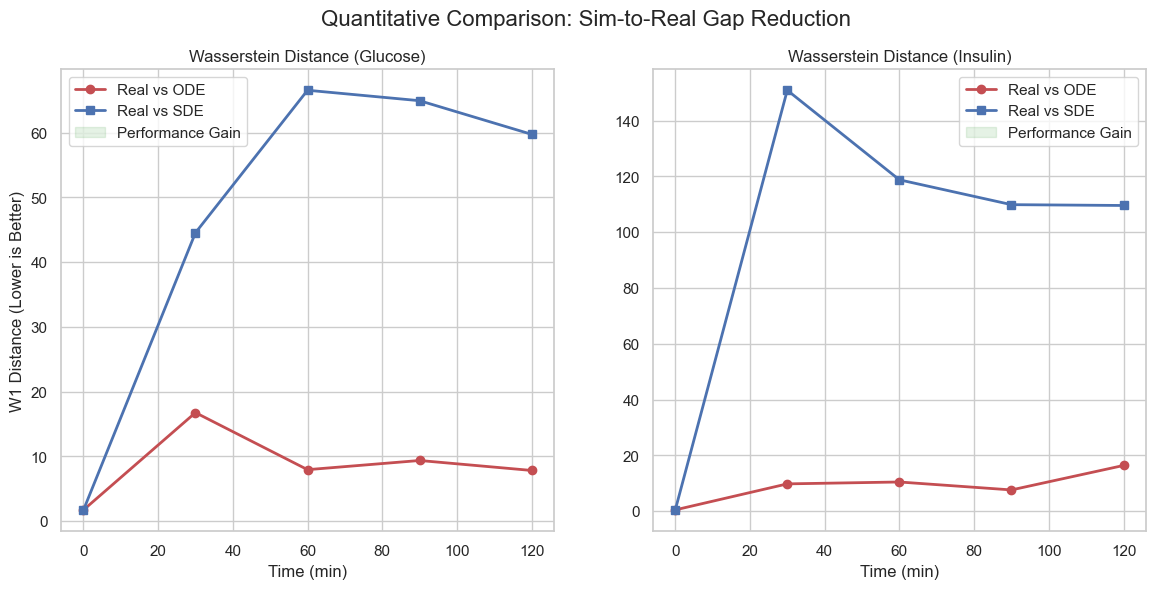

=== Wasserstein Distance Table ===
          G_ODE      G_SDE      I_ODE       I_SDE
Time                                             
0      1.703656   1.668425   0.450983    0.328878
30    16.751412  44.536223   9.783143  150.866213
60     7.937287  66.552999  10.457820  118.767289
90     9.355182  64.938216   7.611400  109.858303
120    7.814935  59.740704  16.381289  109.566004

=== Average Improvement ===
Glucose Improvement: -38.77
Insulin Improvement: -88.94


In [8]:
w1_results = {'Time': t_points, 
              'G_ODE': [], 'G_SDE': [], 
              'I_ODE': [], 'I_SDE': []}

for i in range(len(t_points)):
    # Glucose
    w1_results['G_ODE'].append(wasserstein_distance(G_real[:, i], G_ode[:, i]))
    w1_results['G_SDE'].append(wasserstein_distance(G_real[:, i], G_sde[:, i]))
    
    # Insulin
    w1_results['I_ODE'].append(wasserstein_distance(I_real[:, i], I_ode[:, i]))
    w1_results['I_SDE'].append(wasserstein_distance(I_real[:, i], I_sde[:, i]))

# 결과 데이터프레임 생성
df_w1 = pd.DataFrame(w1_results)
df_w1.set_index('Time', inplace=True)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Glucose W1
axes[0].plot(df_w1.index, df_w1['G_ODE'], 'r-o', label='Real vs ODE', linewidth=2)
axes[0].plot(df_w1.index, df_w1['G_SDE'], 'b-s', label='Real vs SDE', linewidth=2)
axes[0].fill_between(df_w1.index, df_w1['G_ODE'], df_w1['G_SDE'], where=(df_w1['G_ODE'] > df_w1['G_SDE']), 
                     color='green', alpha=0.1, label='Performance Gain')
axes[0].set_title("Wasserstein Distance (Glucose)")
axes[0].set_xlabel("Time (min)")
axes[0].set_ylabel("W1 Distance (Lower is Better)")
axes[0].legend()
axes[0].grid(True)

# Insulin W1
axes[1].plot(df_w1.index, df_w1['I_ODE'], 'r-o', label='Real vs ODE', linewidth=2)
axes[1].plot(df_w1.index, df_w1['I_SDE'], 'b-s', label='Real vs SDE', linewidth=2)
axes[1].fill_between(df_w1.index, df_w1['I_ODE'], df_w1['I_SDE'], where=(df_w1['I_ODE'] > df_w1['I_SDE']), 
                     color='green', alpha=0.1, label='Performance Gain')
axes[1].set_title("Wasserstein Distance (Insulin)")
axes[1].set_xlabel("Time (min)")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Quantitative Comparison: Sim-to-Real Gap Reduction", fontsize=16)
plt.show()

# 수치 테이블 출력
print("=== Wasserstein Distance Table ===")
print(df_w1)
print("\n=== Average Improvement ===")
print(f"Glucose Improvement: {df_w1['G_ODE'].mean() - df_w1['G_SDE'].mean():.2f}")
print(f"Insulin Improvement: {df_w1['I_ODE'].mean() - df_w1['I_SDE'].mean():.2f}")